# 2D PhC Bandgap Notebook (from H5 sample)

So the paper used CNN to predict the band structure showed in Figure 1(B). This band structure includes much information, but what we care more about is the (band gap size) and the (gap-to-midgap ratio) which direct meet the design goal: such as design a PhC device which can filter 1540nm to 1560 nm wavelength, rather than to know what the band structure is.

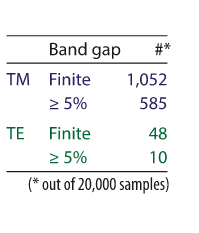

Also from the paper Figure1:D, TM data has more design with band gap 1052, probably we can use this as a start. 

In [2]:
from pathlib import Path
import h5py
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120

In [3]:
# ---- Load one sample from filtered file (fallback-safe) ----
base_dir = Path.cwd()
if not (base_dir / 'data').exists():
    base_dir = Path.cwd() / '2D_PhC'

file_path = base_dir / 'data' / 'square-lattice-te-res64-filtered.h5'
preferred_sample_id = '10781'

with h5py.File(file_path, 'r') as f:
    shape_ids = list(f['shapes'].keys())
    if not shape_ids:
        raise ValueError("No samples found under 'shapes'.")

    sample_id = preferred_sample_id if preferred_sample_id in f['shapes'] else shape_ids[0]
    sample = f['shapes'][sample_id]

    epsilon = sample['unitcell']['epsilon'][:]
    epsin = sample['unitcell']['epsin'][()]
    epsout = sample['unitcell']['epsout'][()]

    kvecs = sample['kvecs'][:]
    freqs = sample['eigfreqs'][:]
    gap_info = sample['bandgap_1'][:].reshape(-1)

# Normalize shapes
if kvecs.shape[0] == 2 and kvecs.shape[1] > 2:
    kvecs = kvecs.T
if freqs.shape[0] < freqs.shape[1]:
    freqs = freqs.T

kx = kvecs[:, 0]
ky = kvecs[:, 1]
num_bands = freqs.shape[1]

band1 = freqs[:, 0]
band2 = freqs[:, 1]

i_max1 = int(np.argmax(band1))
i_min2 = int(np.argmin(band2))
f1_max = float(band1[i_max1])
f2_min = float(band2[i_min2])
gap_computed = f2_min - f1_max

gap_size_h5 = float(gap_info[0]) if gap_info.size > 0 else np.nan
gap_to_mid_h5 = float(gap_info[1]) if gap_info.size > 1 else np.nan

print(f'Using sample_id: {sample_id}')
print(f'epsin={epsin}, epsout={epsout}')
print(f'kvecs shape={kvecs.shape}, freqs shape={freqs.shape}, num_bands={num_bands}')
print(f'Band1 max={f1_max:.6f}, Band2 min={f2_min:.6f}, computed gap={gap_computed:.6f}')
print(f'H5 bandgap_1 = {gap_info}')

Using sample_id: 10781
epsin=[1.01156332], epsout=[7.5640379]
kvecs shape=(529, 2), freqs shape=(529, 6), num_bands=6
Band1 max=0.297993, Band2 min=0.311936, computed gap=0.013943
H5 bandgap_1 = [0.013943   0.04572008]


## 1) Sample unit-cell image
`epsilon` is the dielectric map used for simulation.

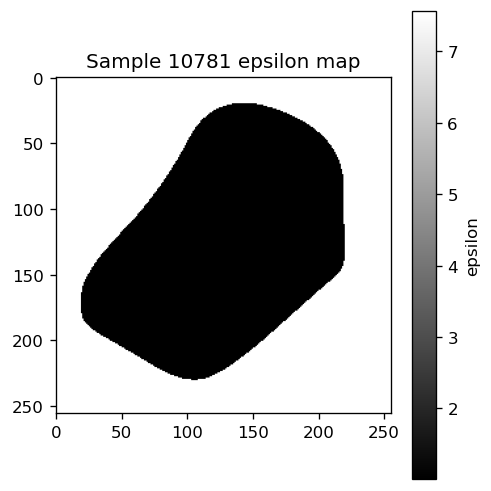

In [4]:
plt.figure(figsize=(4.2, 4.2))
plt.imshow(epsilon, cmap='gray')
plt.title(f'Sample {sample_id} epsilon map')
plt.colorbar(label='epsilon')
plt.tight_layout()
plt.show()

## 2) Bandgap in full-band 3D
Each surface is one photonic band in `(kx, ky, frequency)`.
A full bandgap appears where no band exists in a frequency window over the Brillouin path/sample points. Aimilari as the paper Figure 1.B

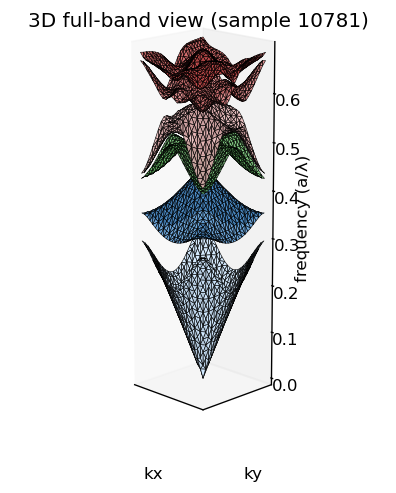

In [7]:
fig = plt.figure(figsize=(3.4, 8.0))
ax = fig.add_subplot(111, projection='3d')

colors = ['#cfe8ff', '#4f93d2', '#6cc36b', '#e8b6b6', '#d97777', '#c94f4f']
for bi in range(min(num_bands, len(colors))):
    ax.plot_trisurf(
        kx, ky, freqs[:, bi],
        color=colors[bi], edgecolor='k', linewidth=0.35, alpha=0.82,
        shade=False, antialiased=True
    )

ax.set_title(f'3D full-band view (sample {sample_id})')
ax.set_xlabel('kx')
ax.set_ylabel('ky')
ax.set_zlabel('frequency (a/λ)')
ax.view_init(elev=16, azim=-45)
ax.set_box_aspect((1, 1, 3.6))
ax.set_xticks([])
ax.set_yticks([])
ax.grid(False)
plt.tight_layout()
plt.show()

## 3) We only consider the first two band
For a complete gap between band 1 and band 2, we use:
- top of band 1: `max(band1)`
- bottom of band 2: `min(band2)`
- gap estimate: `min(band2) - max(band1)`

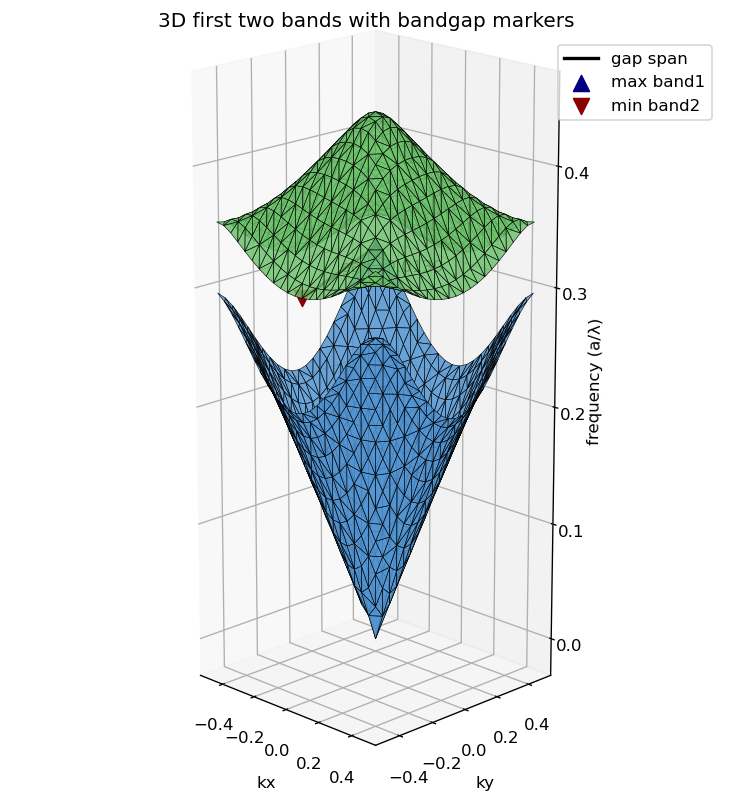

In [6]:
fig = plt.figure(figsize=(6.2, 7.0))
ax = fig.add_subplot(111, projection='3d')

ax.plot_trisurf(kx, ky, band1, color='#4f93d2', edgecolor='k', linewidth=0.35, alpha=0.84, shade=False)
ax.plot_trisurf(kx, ky, band2, color='#6cc36b', edgecolor='k', linewidth=0.35, alpha=0.84, shade=False)

ax.scatter(kx[i_max1], ky[i_max1], f1_max, s=90, color='navy', marker='^', label='max band1')
ax.scatter(kx[i_min2], ky[i_min2], f2_min, s=90, color='darkred', marker='v', label='min band2')
ax.plot([kx[i_max1], kx[i_min2]], [ky[i_max1], ky[i_min2]], [f1_max, f2_min],
        color='black', linewidth=2.0, label='gap span')

ax.text(
    (kx[i_max1] + kx[i_min2]) / 2,
    (ky[i_max1] + ky[i_min2]) / 2,
    (f1_max + f2_min) / 2,
    f'gap={gap_computed:.4f}',
    fontsize=10
)

ax.set_title('3D first two bands with bandgap markers')
ax.set_xlabel('kx')
ax.set_ylabel('ky')
ax.set_zlabel('frequency (a/λ)')
ax.view_init(elev=18, azim=-45)
ax.set_box_aspect((1, 1, 2.5))
ax.legend(loc='best')
plt.tight_layout()
plt.show()

## 4) 2D views: frequency vs kx and frequency vs ky
These help you see where band1 top / band2 bottom sit and the vertical bandgap interval.

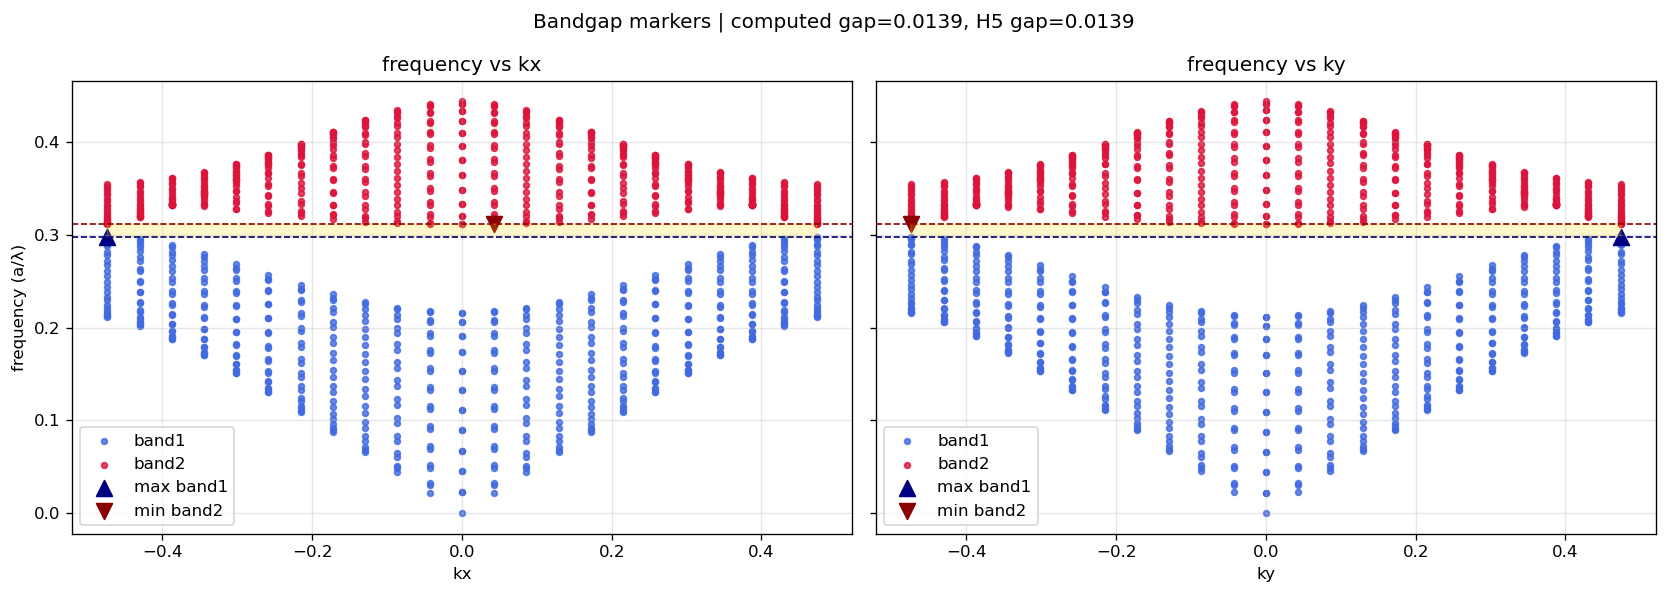

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# frequency vs kx
ax1.scatter(kx, band1, s=12, color='royalblue', alpha=0.8, label='band1')
ax1.scatter(kx, band2, s=12, color='crimson', alpha=0.8, label='band2')
ax1.scatter(kx[i_max1], f1_max, s=90, color='navy', marker='^', label='max band1')
ax1.scatter(kx[i_min2], f2_min, s=90, color='darkred', marker='v', label='min band2')
ax1.axhline(f1_max, color='navy', linestyle='--', linewidth=1)
ax1.axhline(f2_min, color='darkred', linestyle='--', linewidth=1)
if gap_computed > 0:
    ax1.fill_between([kx.min(), kx.max()], [f1_max, f1_max], [f2_min, f2_min], color='gold', alpha=0.2)
ax1.set_title('frequency vs kx')
ax1.set_xlabel('kx')
ax1.set_ylabel('frequency (a/λ)')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best')

# frequency vs ky
ax2.scatter(ky, band1, s=12, color='royalblue', alpha=0.8, label='band1')
ax2.scatter(ky, band2, s=12, color='crimson', alpha=0.8, label='band2')
ax2.scatter(ky[i_max1], f1_max, s=90, color='navy', marker='^', label='max band1')
ax2.scatter(ky[i_min2], f2_min, s=90, color='darkred', marker='v', label='min band2')
ax2.axhline(f1_max, color='navy', linestyle='--', linewidth=1)
ax2.axhline(f2_min, color='darkred', linestyle='--', linewidth=1)
if gap_computed > 0:
    ax2.fill_between([ky.min(), ky.max()], [f1_max, f1_max], [f2_min, f2_min], color='gold', alpha=0.2)
ax2.set_title('frequency vs ky')
ax2.set_xlabel('ky')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='best')

plt.suptitle(f'Bandgap markers | computed gap={gap_computed:.4f}, H5 gap={gap_size_h5:.4f}')
plt.tight_layout()
plt.show()

The yellow area represents the bandgap. the fequencey difference between max and min marker is the bandsize

## 5) How to get bandgap size directly from H5
In dataset, `bandgap_1` stores two values:
- `bandgap_1[0]`: absolute normalized gap width $\Delta \omega$
- `bandgap_1[1]`: gap-to-midgap ratio $\Delta \omega / \omega_{mid}$

You can recover mid-gap normalized frequency (The center of yellow band) by
$$\omega_{mid} = \frac{\Delta \omega}{\Delta \omega/\omega_{mid}}$$

In [11]:
delta_omega = gap_size_h5
ratio = gap_to_mid_h5

omega_mid = delta_omega / ratio if np.isfinite(delta_omega) and np.isfinite(ratio) and ratio > 0 else np.nan

print(f'From H5: Δω = {delta_omega:.6f}')
print(f'From H5: Δω/ω_mid = {ratio:.6f}')
print(f'Computed ω_mid = Δω / (Δω/ω_mid) = {omega_mid:.6f}')

From H5: Δω = 0.013943
From H5: Δω/ω_mid = 0.045720
Computed ω_mid = Δω / (Δω/ω_mid) = 0.304964


## 6) Translate normalized values to reality at 1550 nm
In PhC normalized units:
$$
\frac{\omega a}{2\pi c} = \frac{a}{\lambda}
$$
So if $a/\lambda_{mid} = \omega_{mid}$ and you target $\lambda_{mid}=1550$ nm:
$$
a = \omega_{mid} \cdot \lambda_{mid}
$$

In [12]:
lambda_mid_nm = 1550.0

a_nm = omega_mid * lambda_mid_nm if np.isfinite(omega_mid) else np.nan

if np.isfinite(omega_mid):
    lambda_low_nm = a_nm / (omega_mid + delta_omega / 2)
    lambda_high_nm = a_nm / (omega_mid - delta_omega / 2)
else:
    lambda_low_nm = np.nan
    lambda_high_nm = np.nan

print(f'omega_mid (normalized) = {omega_mid:.6f}')
print(f'For λ_mid = 1550 nm -> lattice constant a ≈ {a_nm:.2f} nm')
print(f'Approx stopband in wavelength: [{lambda_low_nm:.1f}, {lambda_high_nm:.1f}] nm')

omega_mid (normalized) = 0.304964
For λ_mid = 1550 nm -> lattice constant a ≈ 472.69 nm
Approx stopband in wavelength: [1515.4, 1586.3] nm


## 7) Approximate reflection/transmission spectrum (intuition only)
This is a **toy model** to show expected behavior if this PhC is used as a slab/filter:
- high reflection inside stopband,
- high transmission outside stopband.

For accurate spectra, you need full-wave simulation (FDTD/FEM/RCWA) with thickness, interfaces, and losses.

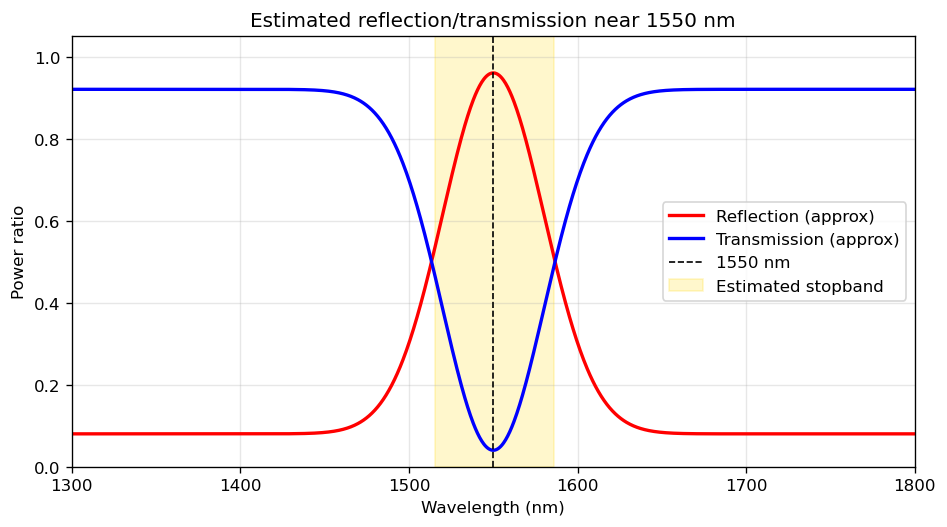

In [13]:
lam = np.linspace(1300, 1800, 1200)

if np.isfinite(lambda_low_nm) and np.isfinite(lambda_high_nm):
    lam0 = 1550.0
    bw = max((lambda_high_nm - lambda_low_nm), 1e-6)

    # Gaussian-like stopband around lam0 with width tied to estimated gap
    sigma = bw / 2.355  # FWHM ~ bw
    R = 0.08 + 0.88 * np.exp(-0.5 * ((lam - lam0) / sigma) ** 2)
    T = 1.0 - R
    R = np.clip(R, 0, 1)
    T = np.clip(T, 0, 1)
else:
    R = np.full_like(lam, np.nan)
    T = np.full_like(lam, np.nan)

plt.figure(figsize=(8, 4.5))
plt.plot(lam, R, 'r', lw=2, label='Reflection (approx)')
plt.plot(lam, T, 'b', lw=2, label='Transmission (approx)')
if np.isfinite(lambda_low_nm) and np.isfinite(lambda_high_nm):
    plt.axvspan(lambda_low_nm, lambda_high_nm, color='gold', alpha=0.2, label='Estimated stopband')
plt.axvline(1550, color='k', ls='--', lw=1, label='1550 nm')
plt.ylim(0, 1.05)
plt.xlim(lam.min(), lam.max())
plt.xlabel('Wavelength (nm)')
plt.ylabel('Power ratio')
plt.title('Estimated reflection/transmission near 1550 nm')
plt.grid(True, alpha=0.3)
plt.legend(loc='best')
plt.tight_layout()
plt.show()